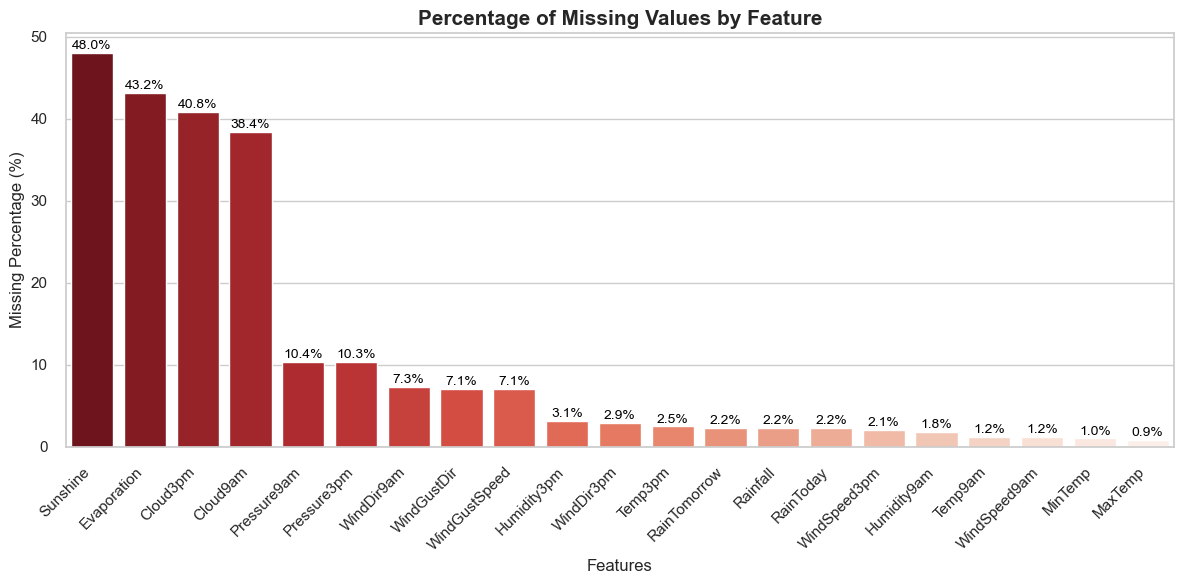

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 绘图风格设置
sns.set(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
try:
    df = pd.read_csv('weatherAUS.csv')
except FileNotFoundError:
    print("错误：未找到 weatherAUS.csv，使用模拟数据演示。")
    data = {'A': [1, 2, np.nan], 'B': [1, np.nan, np.nan], 'C': [1, 2, 3]}
    df = pd.DataFrame(data)

# 计算缺失值比例
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_data = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if missing_data.empty:
    print("数据集中没有缺失值。")
else:
    # 绘制缺失值分布图
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=missing_data.index, y=missing_data.values, palette="Reds_r")

    # 设置标题和标签
    plt.title('Percentage of Missing Values by Feature', fontsize=15, fontweight='bold')
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)

    # 调整X轴标签角度
    plt.xticks(rotation=45, ha='right')

    # 添加数值标注
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    fontsize=10, color='black', 
                    xytext=(0, 5), 
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()

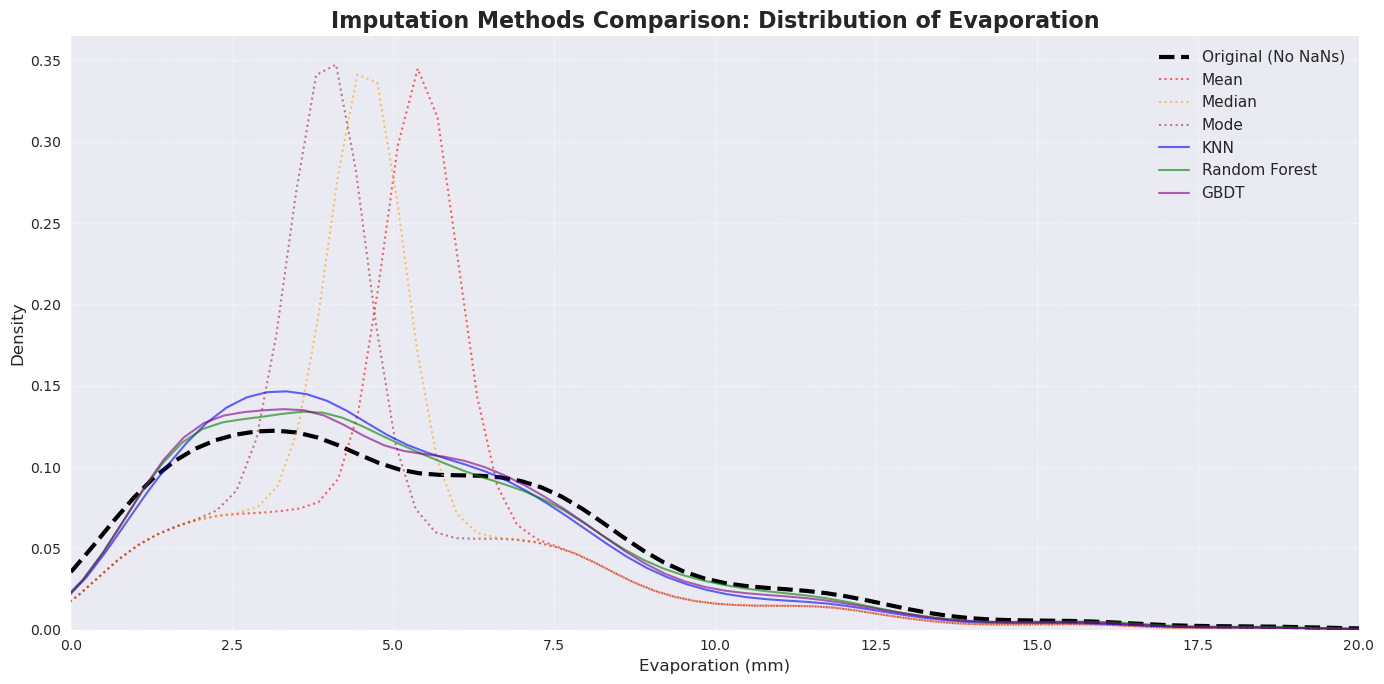

分析目标: Evaporation
原始基准: 均值=5.42, 标准差=4.13

           方法   均值    均值偏差  标准差   标准差偏差
         Mean 5.42  +0.00% 3.15 -23.75%
       Median 5.08  -6.32% 3.17 -23.13%
         Mode 4.82 -10.95% 3.22 -21.89%
          KNN 5.08  -6.31% 3.55 -13.94%
Random Forest 5.23  -3.46% 3.68 -10.70%
         GBDT 5.17  -4.54% 3.65 -11.58%


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

# 配置
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 数据加载
file_path = 'weatherAUS.csv'
try:
    df_raw = pd.read_csv(file_path)
except FileNotFoundError:
    print("错误：找不到文件。")
    exit()

# 目标变量设定与采样
target_col = 'Evaporation'
df_sample = df_raw.sample(n=5000, random_state=42).copy()
numeric_df = df_sample.select_dtypes(include=[np.number])
original_data = numeric_df[target_col].dropna()

# 定义填补方法
methods = {}

# 1. 统计学方法
methods['Mean'] = SimpleImputer(strategy='mean').fit_transform(numeric_df)[:, numeric_df.columns.get_loc(target_col)]
methods['Median'] = SimpleImputer(strategy='median').fit_transform(numeric_df)[:, numeric_df.columns.get_loc(target_col)]
methods['Mode'] = SimpleImputer(strategy='most_frequent').fit_transform(numeric_df)[:, numeric_df.columns.get_loc(target_col)]

# 2. KNN (需归一化)
scaler = MinMaxScaler()
numeric_scaled = pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns)
knn_filled = KNNImputer(n_neighbors=5).fit_transform(numeric_scaled)
methods['KNN'] = scaler.inverse_transform(knn_filled)[:, numeric_df.columns.get_loc(target_col)]

# 3. 机器学习迭代填补
methods['Random Forest'] = IterativeImputer(estimator=RandomForestRegressor(n_jobs=-1, random_state=42), max_iter=5).fit_transform(numeric_df)[:, numeric_df.columns.get_loc(target_col)]
methods['GBDT'] = IterativeImputer(estimator=GradientBoostingRegressor(random_state=42), max_iter=5).fit_transform(numeric_df)[:, numeric_df.columns.get_loc(target_col)]

# 计算统计差异
stats_report = []
orig_mean = original_data.mean()
orig_std = original_data.std()
method_order = ['Mean', 'Median', 'Mode', 'KNN', 'Random Forest', 'GBDT']

for name in method_order:
    data = methods[name]
    new_mean = data.mean()
    new_std = data.std()
    
    stats_report.append({
        '方法': name,
        '均值': f"{new_mean:.2f}",
        '均值偏差': f"{(new_mean - orig_mean) / orig_mean * 100:+.2f}%",
        '标准差': f"{new_std:.2f}",
        '标准差偏差': f"{(new_std - orig_std) / orig_std * 100:+.2f}%"
    })

# 绘图对比
plt.figure(figsize=(14, 7))
sns.kdeplot(original_data, label='Original (No NaNs)', color='black', linestyle='--', linewidth=3)

style_map = {
    'Mean': {'color': 'red', 'ls': ':'},
    'Median': {'color': 'orange', 'ls': ':'},
    'Mode': {'color': 'brown', 'ls': ':'},
    'KNN': {'color': 'blue', 'ls': '-'},
    'Random Forest': {'color': 'green', 'ls': '-'},
    'GBDT': {'color': 'purple', 'ls': '-'}
}

for name in method_order:
    cfg = style_map[name]
    sns.kdeplot(methods[name], label=name, color=cfg['color'], linestyle=cfg['ls'], alpha=0.6, linewidth=1.5)

plt.title(f'Imputation Methods Comparison: Distribution of {target_col}', fontsize=16, fontweight='bold')
plt.xlabel('Evaporation (mm)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.xlim(0, 20)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 输出报告
print(f"分析目标: {target_col}")
print(f"原始基准: 均值={orig_mean:.2f}, 标准差={orig_std:.2f}\n")
print(pd.DataFrame(stats_report).to_string(index=False))


In [18]:
import pandas as pd
import numpy as np
import warnings
import time
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# 数据加载
file_path = 'weatherAUS.csv'
try:
    df_orig = pd.read_csv(file_path)
except FileNotFoundError:
    print("Error: File not found.")
    exit()

# 删除无标签样本
df_orig = df_orig.dropna(subset=['RainTomorrow'])

# 构建计算用副本
df_calc = df_orig.copy()

# 预处理：日期转数值
df_calc['Date'] = pd.to_datetime(df_calc['Date']).map(pd.Timestamp.toordinal)

# 预处理：类别变量编码 (保留 NaN 用于 KNN 计算)
encoders = {}
object_cols = df_calc.select_dtypes(include=['object']).columns

for col in object_cols:
    series = df_calc[col]
    uniques = series.dropna().unique()
    mapping = {val: i for i, val in enumerate(uniques)}
    encoders[col] = {i: val for val, i in mapping.items()} # 保存映射字典用于还原
    df_calc[col] = series.map(mapping)

# 预处理：归一化
scaler = MinMaxScaler()
columns_list = df_calc.columns
df_calc_scaled = pd.DataFrame(scaler.fit_transform(df_calc), columns=columns_list, index=df_calc.index)

# 分层抽样构建参考库 (n=5000)
stratify_col = df_orig['RainTomorrow']
X_sample, _, _, _ = train_test_split(
    df_calc_scaled, stratify_col,
    train_size=5000,
    stratify=stratify_col,
    random_state=42
)

# 执行 KNN 填补
print(f"Running KNN Imputation (Sample size: {len(X_sample)})...")
start_time = time.time()

knn = KNNImputer(n_neighbors=5)
knn.fit(X_sample)
df_filled_array = knn.transform(df_calc_scaled)
df_filled_scaled = pd.DataFrame(df_filled_array, columns=columns_list, index=df_calc.index)

print(f"Imputation done in {time.time() - start_time:.2f}s")

# 数据还原与回填
df_filled_numeric = pd.DataFrame(scaler.inverse_transform(df_filled_scaled), columns=columns_list, index=df_calc.index)

for col in df_orig.columns:
    if df_orig[col].isnull().sum() > 0:
        filled_series = df_filled_numeric[col]
        
        # 类别变量还原
        if col in encoders:
            filled_series = filled_series.round().astype(int)
            filled_series = filled_series.map(encoders[col])
        else:
            # 数值变量保留一位小数
            filled_series = filled_series.round(1)
            
        # 仅填充原数据中的缺失值
        df_orig[col] = df_orig[col].fillna(filled_series)

# 保存结果
remaining_nans = df_orig.isnull().sum().sum()
output_file = 'weatherAUS_KNN_Patched.csv'
df_orig.to_csv(output_file, index=False)

print(f"Remaining NaNs: {remaining_nans}")
print(f"File saved to: {output_file}")

Running KNN Imputation (Sample size: 5000)...
Imputation done in 26.54s
Remaining NaNs: 0
File saved to: weatherAUS_KNN_Patched.csv


In [20]:
import pandas as pd

# 加载数据 (KNN填补后的版本)
df = pd.read_csv('weatherAUS_KNN_Patched.csv')

# 定义需要检测偏度的连续变量
cols_to_check = [
    'Rainfall', 'Evaporation', 'Sunshine', 
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 
    'Pressure9am', 'Pressure3pm', 
    'Cloud9am', 'Cloud3pm', 
    'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm'
]

# 过滤有效列
valid_cols = [c for c in cols_to_check if c in df.columns]

# 计算偏度并降序排列
skew_results = df[valid_cols].skew().sort_values(ascending=False)

# 输出结果
print(f"{'Variable':<18} | {'Skew':<8} | {'Level'}")

for col, val in skew_results.items():
    # 阈值判断：绝对值>1为高度偏态，>0.5为中度
    if abs(val) > 1:
        level = "High Skew (>1)"
    elif abs(val) > 0.5:
        level = "Moderate Skew"
    else:
        level = "Symmetric"
        
    print(f"{col:<18} | {val:.4f}   | {level}")

Variable           | Skew     | Level
Rainfall           | 9.8811   | High Skew (>1)
Evaporation        | 3.7484   | High Skew (>1)
WindGustSpeed      | 0.8896   | Moderate Skew
WindSpeed9am       | 0.7774   | Moderate Skew
WindSpeed3pm       | 0.6376   | Moderate Skew
Temp3pm            | 0.2326   | Symmetric
MaxTemp            | 0.2247   | Symmetric
Temp9am            | 0.0918   | Symmetric
Humidity3pm        | 0.0301   | Symmetric
MinTemp            | 0.0231   | Symmetric
Pressure3pm        | -0.0849   | Symmetric
Pressure9am        | -0.1345   | Symmetric
Cloud3pm           | -0.1411   | Symmetric
Cloud9am           | -0.2225   | Symmetric
Sunshine           | -0.4534   | Symmetric
Humidity9am        | -0.4898   | Symmetric


Dataset loaded: weatherAUS_KNN_Patched.csv
Plot saved to yeo_johnson_final_comparison.png


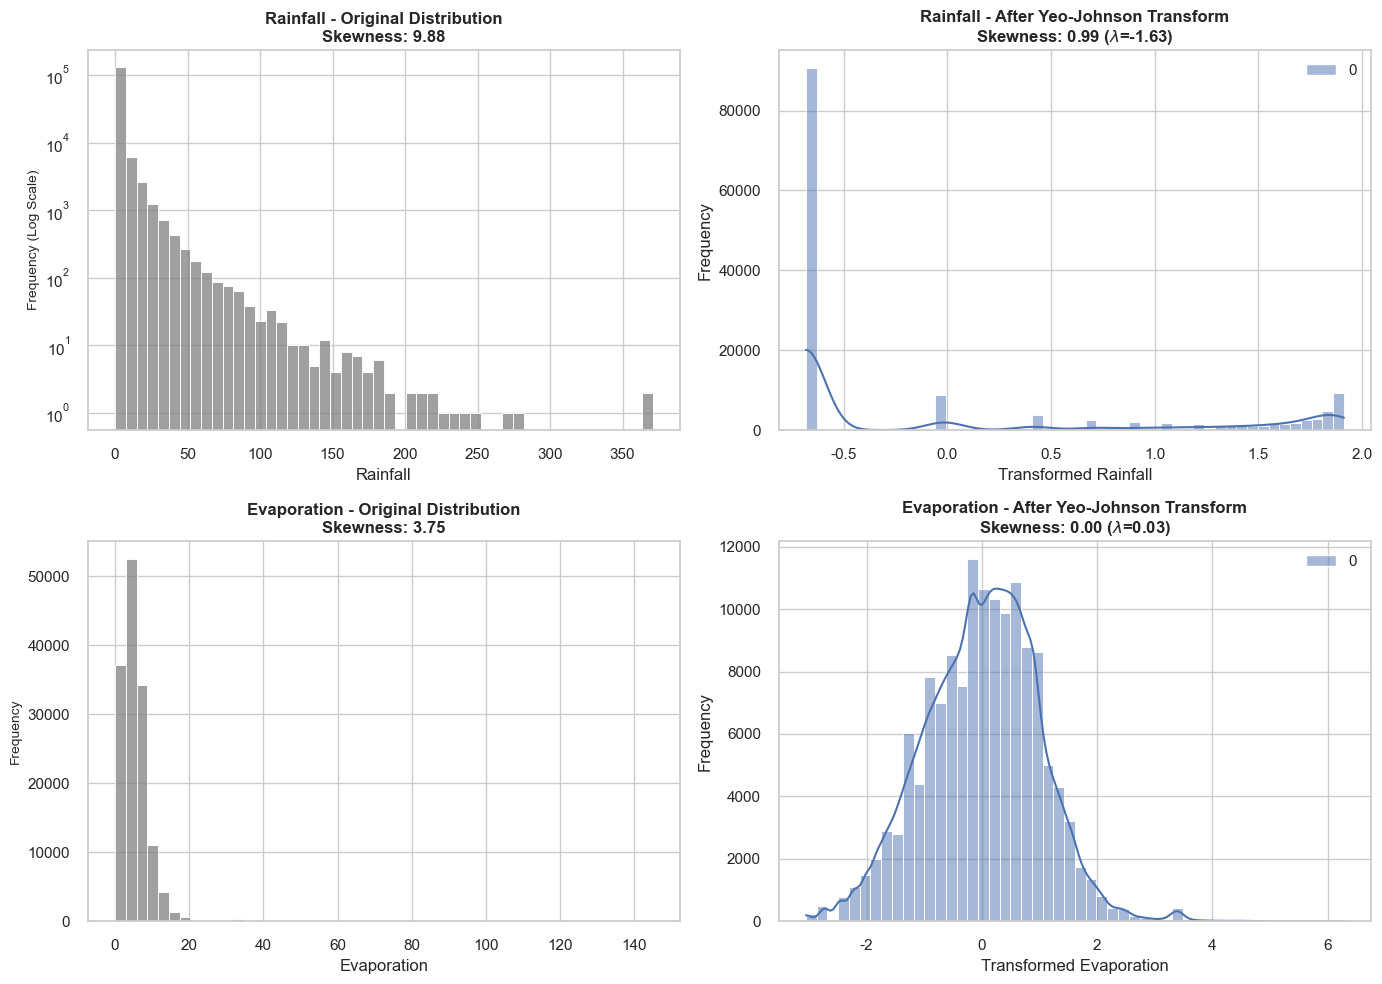

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# 数据加载
filename = 'weatherAUS_KNN_Patched.csv'
try:
    df = pd.read_csv(filename)
    print(f"Dataset loaded: {filename}")
except FileNotFoundError:
    print(f"Warning: {filename} not found. Using dummy data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'Rainfall': np.append(np.zeros(3000), np.random.exponential(5, 2000)),
        'Evaporation': np.random.gamma(2, 2, 5000)
    })

# 绘图风格设置
sns.set(style="whitegrid")

# 定义绘图逻辑
target_cols = ['Rainfall', 'Evaporation']
fig, axes = plt.subplots(len(target_cols), 2, figsize=(14, 10))

for i, col in enumerate(target_cols):
    if col not in df.columns:
        continue
        
    # 数据准备
    original_data = df[[col]].dropna()
    
    # Yeo-Johnson 变换
    pt = PowerTransformer(method='yeo-johnson')
    transformed_data = pt.fit_transform(original_data)
    
    # 计算偏度
    skew_orig = original_data[col].skew()
    skew_trans = pd.DataFrame(transformed_data)[0].skew()
    lambda_val = pt.lambdas_[0] 

    # 绘制左图: 原始分布
    ax_left = axes[i, 0]
    sns.histplot(original_data, x=col, bins=50, ax=ax_left, color='gray', kde=False)
    
    ax_left.set_title(f'{col} - Original Distribution\nSkewness: {skew_orig:.2f}', fontsize=12, fontweight='bold')
    
    # Rainfall 使用对数坐标以便观察
    if col == 'Rainfall':
        ax_left.set_yscale('log')
        ax_left.set_ylabel('Frequency (Log Scale)', fontsize=10)
    else:
        ax_left.set_ylabel('Frequency', fontsize=10)

    # 绘制右图: 变换后分布
    ax_right = axes[i, 1]
    sns.histplot(transformed_data, bins=50, ax=ax_right, color='#2ecc71', kde=True)
    
    ax_right.set_title(f'{col} - After Yeo-Johnson Transform\nSkewness: {skew_trans:.2f} ($\lambda$={lambda_val:.2f})', fontsize=12, fontweight='bold')
    ax_right.set_xlabel(f'Transformed {col}')
    ax_right.set_ylabel('Frequency')

# 保存结果
plt.tight_layout()
output_filename = 'yeo_johnson_final_comparison.png'
plt.savefig(output_filename, dpi=300)
print(f"Plot saved to {output_filename}")
plt.show()

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载数据
df = pd.read_csv('weatherAUS_KNN_Patched.csv')

# 温度逻辑检查 (最低温 > 最高温)
err_temp = df[df['MinTemp'] > df['MaxTemp']]
print(f"MinTemp > MaxTemp exceptions: {len(err_temp)}")

# 降雨量非负检查
err_rain = df[df['Rainfall'] < 0]
print(f"Rainfall < 0 exceptions: {len(err_rain)}")

# 风速非负检查
wind_cols = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
for col in wind_cols:
    if col in df.columns:
        err_wind = df[df[col] < 0]
        print(f"{col} < 0 exceptions: {len(err_wind)}")

MinTemp > MaxTemp exceptions: 7
Rainfall < 0 exceptions: 0
WindGustSpeed < 0 exceptions: 0
WindSpeed9am < 0 exceptions: 0
WindSpeed3pm < 0 exceptions: 0


In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer

# 配置路径
input_filename = 'weatherAUS_KNN_Patched.csv'
output_filename = 'weatherAUS_Transformed.csv'

# 加载数据
try:
    df = pd.read_csv(input_filename)
    print(f"Data loaded: {input_filename} | Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: {input_filename} not found.")
    # 模拟数据防止运行中断
    df = pd.DataFrame({
        'Rainfall': np.random.exponential(5, 1000), 
        'Evaporation': np.random.gamma(2, 2, 1000),
        'WindGustSpeed': np.random.normal(40, 10, 1000)
    })

# Yeo-Johnson 变换
# 针对 Rainfall 和 Evaporation 进行偏度修正并标准化
cols_to_transform = ['Rainfall', 'Evaporation']
pt = PowerTransformer(method='yeo-johnson', standardize=True)

print("\nRunning Yeo-Johnson transformation...")
df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

# 输出变换参数 (Lambda)
print(f"Optimal Lambda (Rainfall): {pt.lambdas_[0]:.4f}")
print(f"Optimal Lambda (Evaporation): {pt.lambdas_[1]:.4f}")

# 检查变换后偏度
print("\nPost-transform Skewness:")
print(df[cols_to_transform].skew())

# 保存结果
df.to_csv(output_filename, index=False)
print(f"\nDataset saved to: {output_filename}")

Data loaded: weatherAUS_KNN_Patched.csv | Shape: (142193, 23)

Running Yeo-Johnson transformation...
Optimal Lambda (Rainfall): -1.6309
Optimal Lambda (Evaporation): 0.0265

Post-transform Skewness:
Rainfall       0.991493
Evaporation    0.001761
dtype: float64

Dataset saved to: weatherAUS_Transformed.csv


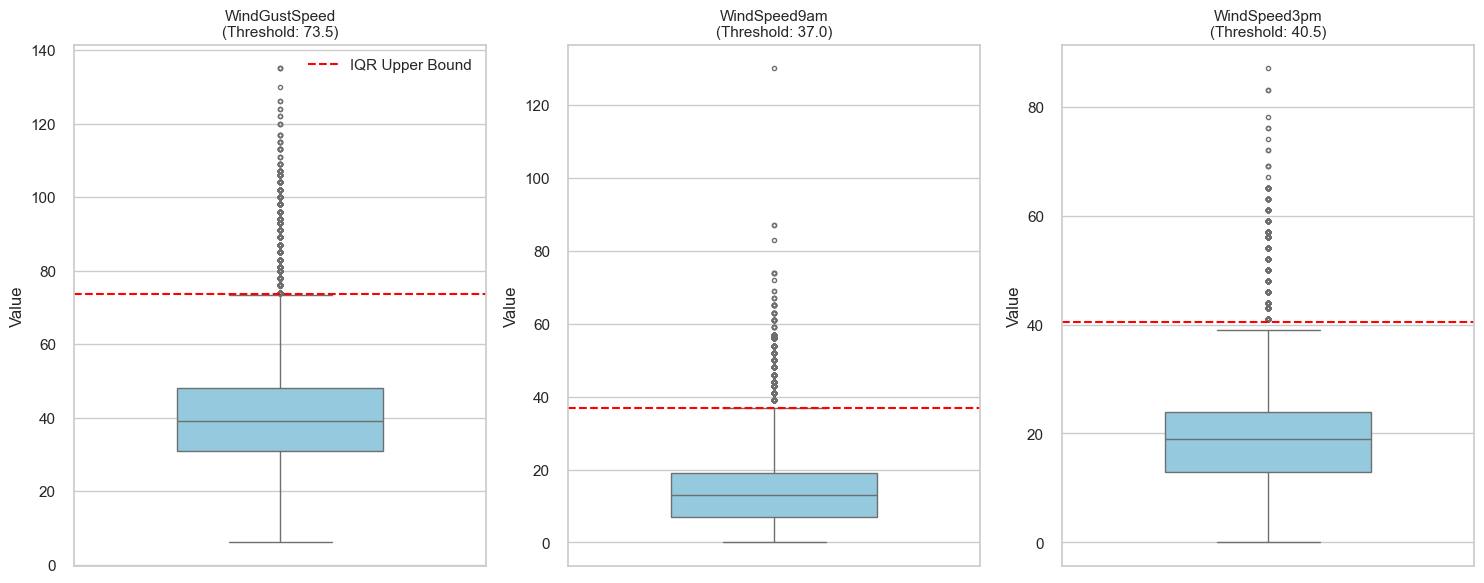

Z-score Outlier Check (Threshold: |Z| > 3):
 - MinTemp     : 19 outliers found (0.01%)
 - MaxTemp     : 309 outliers found (0.22%)
 - Pressure9am : 627 outliers found (0.44%)
 - Pressure3pm : 520 outliers found (0.37%)
 - Humidity9am : 471 outliers found (0.33%)
 - Humidity3pm : 0 outliers found (0.00%)
 - Temp9am     : 134 outliers found (0.09%)
 - Temp3pm     : 385 outliers found (0.27%)


In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 加载数据
df = pd.read_csv('weatherAUS_Transformed.csv')

# 绘图配置
sns.set(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(15, 6))

# 1. IQR 异常值可视化 (针对偏态分布变量)
iqr_vars = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
iqr_vars = [c for c in iqr_vars if c in df.columns]

for i, col in enumerate(iqr_vars):
    plt.subplot(1, len(iqr_vars), i+1)
    
    # 绘制箱线图
    sns.boxplot(y=df[col], color='skyblue', width=0.5, fliersize=3)
    
    # 计算 IQR 上界
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # 添加阈值辅助线
    plt.axhline(upper_bound, color='red', linestyle='--', label='IQR Upper Bound')
    plt.title(f'{col}\n(Threshold: {upper_bound:.1f})', fontsize=11)
    plt.ylabel('Value')
    
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()

# 2. Z-score 异常值统计 (针对正态分布变量)
normal_vars = ['MinTemp', 'MaxTemp', 'Pressure9am', 'Pressure3pm', 
               'Humidity9am', 'Humidity3pm', 'Temp9am', 'Temp3pm']

print("Z-score Outlier Check (Threshold: |Z| > 3):")

for col in normal_vars:
    if col in df.columns:
        valid_data = df[col].dropna()
        z_scores = np.abs(stats.zscore(valid_data))
        outlier_count = (z_scores > 3).sum()
        
        print(f" - {col:<12}: {outlier_count} outliers found ({outlier_count/len(df)*100:.2f}%)")

In [30]:
import pandas as pd
import numpy as np

# 加载数据
input_file = 'weatherAUS_Transformed.csv'
df = pd.read_csv(input_file)

def cap_series(series, name):
    # 计算 IQR 上界
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    upper_limit = Q3 + 1.5 * (Q3 - Q1)
    
    # 输出截断统计
    n_outliers = (series > upper_limit).sum()
    print(f"[{name}] Threshold: {upper_limit:.2f} | Outliers: {n_outliers} | Max: {series.max():.2f} -> {upper_limit:.2f}")
    
    # 执行盖帽
    return series.clip(upper=upper_limit)

# 1. 逻辑豁免
print("Skipping truncation for transformed variables (Rainfall, Evaporation).")

# 2. 批量处理风速异常值
wind_cols = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
for col in wind_cols:
    if col in df.columns:
        df[col] = cap_series(df[col], col)

# 保存清洗后数据
df.to_csv('weatherAUS_Final_Cleaned.csv', index=False)
print("Processing complete. File saved.")

Skipping truncation for transformed variables (Rainfall, Evaporation).
[WindGustSpeed] Threshold: 73.50 | Outliers: 3008 | Max: 135.00 -> 73.50
[WindSpeed9am] Threshold: 37.00 | Outliers: 1739 | Max: 130.00 -> 37.00
[WindSpeed3pm] Threshold: 40.50 | Outliers: 2458 | Max: 87.00 -> 40.50
Processing complete. File saved.


In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 加载数据
df = pd.read_csv('weatherAUS_Final_Cleaned.csv')

# 1. 日期特征工程
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# 月份周期性编码
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# 年份标准化
scaler_year = StandardScaler()
df['Year'] = scaler_year.fit_transform(df[['Year']])

# 移除原始时间列
df.drop(['Date', 'Month'], axis=1, inplace=True)

# 2. 二分类变量映射 (Yes/No -> 1/0)
binary_mapping = {'No': 0, 'Yes': 1}
cols_to_map = ['RainToday', 'RainTomorrow']

for col in cols_to_map:
    if df[col].dtype == 'object':
        df[col] = df[col].map(binary_mapping)

# 3. 多分类变量独热编码 (One-Hot)
# drop_first=True 用于避免多重共线性
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# 输出与保存
print("Encoding complete.")
print(f"Final shape: {df.shape}")
print(df.head())

df.to_csv('weatherAUS_Encoded_Final.csv', index=False)
print("File saved: weatherAUS_Encoded_Final.csv")

Encoding complete.
Final shape: (142193, 114)
   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0     13.4     22.9  0.707747     0.523280       7.0           44.0   
1      7.4     25.1 -0.681803     0.419225      10.8           44.0   
2     12.9     25.7 -0.681803     0.337255      11.6           46.0   
3      9.2     28.0 -0.681803     0.826781      11.5           24.0   
4     17.5     32.3  1.075621     0.573243       6.7           41.0   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  WindDir3pm_NNW  \
0          20.0          24.0         71.0         22.0  ...               0   
1           4.0          22.0         44.0         25.0  ...               0   
2          19.0          26.0         38.0         30.0  ...               0   
3          11.0           9.0         45.0         16.0  ...               0   
4           7.0          20.0         82.0         33.0  ...               0   

   WindDir3pm_NW  WindDir3pm_S  WindDir3pm_SE 

In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 加载数据
df = pd.read_csv('weatherAUS_Encoded_Final.csv')

# 定义需要标准化的连续数值变量
cols_to_scale = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
]

# 过滤有效列
valid_cols = [col for col in cols_to_scale if col in df.columns]

# 执行标准化 (Z-Score Normalization)
scaler = StandardScaler()
df[valid_cols] = scaler.fit_transform(df[valid_cols])

# 验证结果 (均值~0, 标准差~1)
print("Standardization Statistics:")
print(df[valid_cols].describe().loc[['mean', 'std']].round(2))

# 保存最终建模数据
output_file = 'weatherAUS_Modeling_Ready.csv'
df.to_csv(output_file, index=False)
print(f"\nModeling dataset saved to: {output_file}")

Standardization Statistics:
      MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
mean      0.0     -0.0      -0.0          0.0       0.0           -0.0   
std       1.0      1.0       1.0          1.0       1.0            1.0   

      WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
mean          -0.0          -0.0          0.0         -0.0          0.0   
std            1.0           1.0          1.0          1.0          1.0   

      Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  
mean          0.0       0.0      -0.0     -0.0      0.0  
std           1.0       1.0       1.0      1.0      1.0  

Modeling dataset saved to: weatherAUS_Modeling_Ready.csv


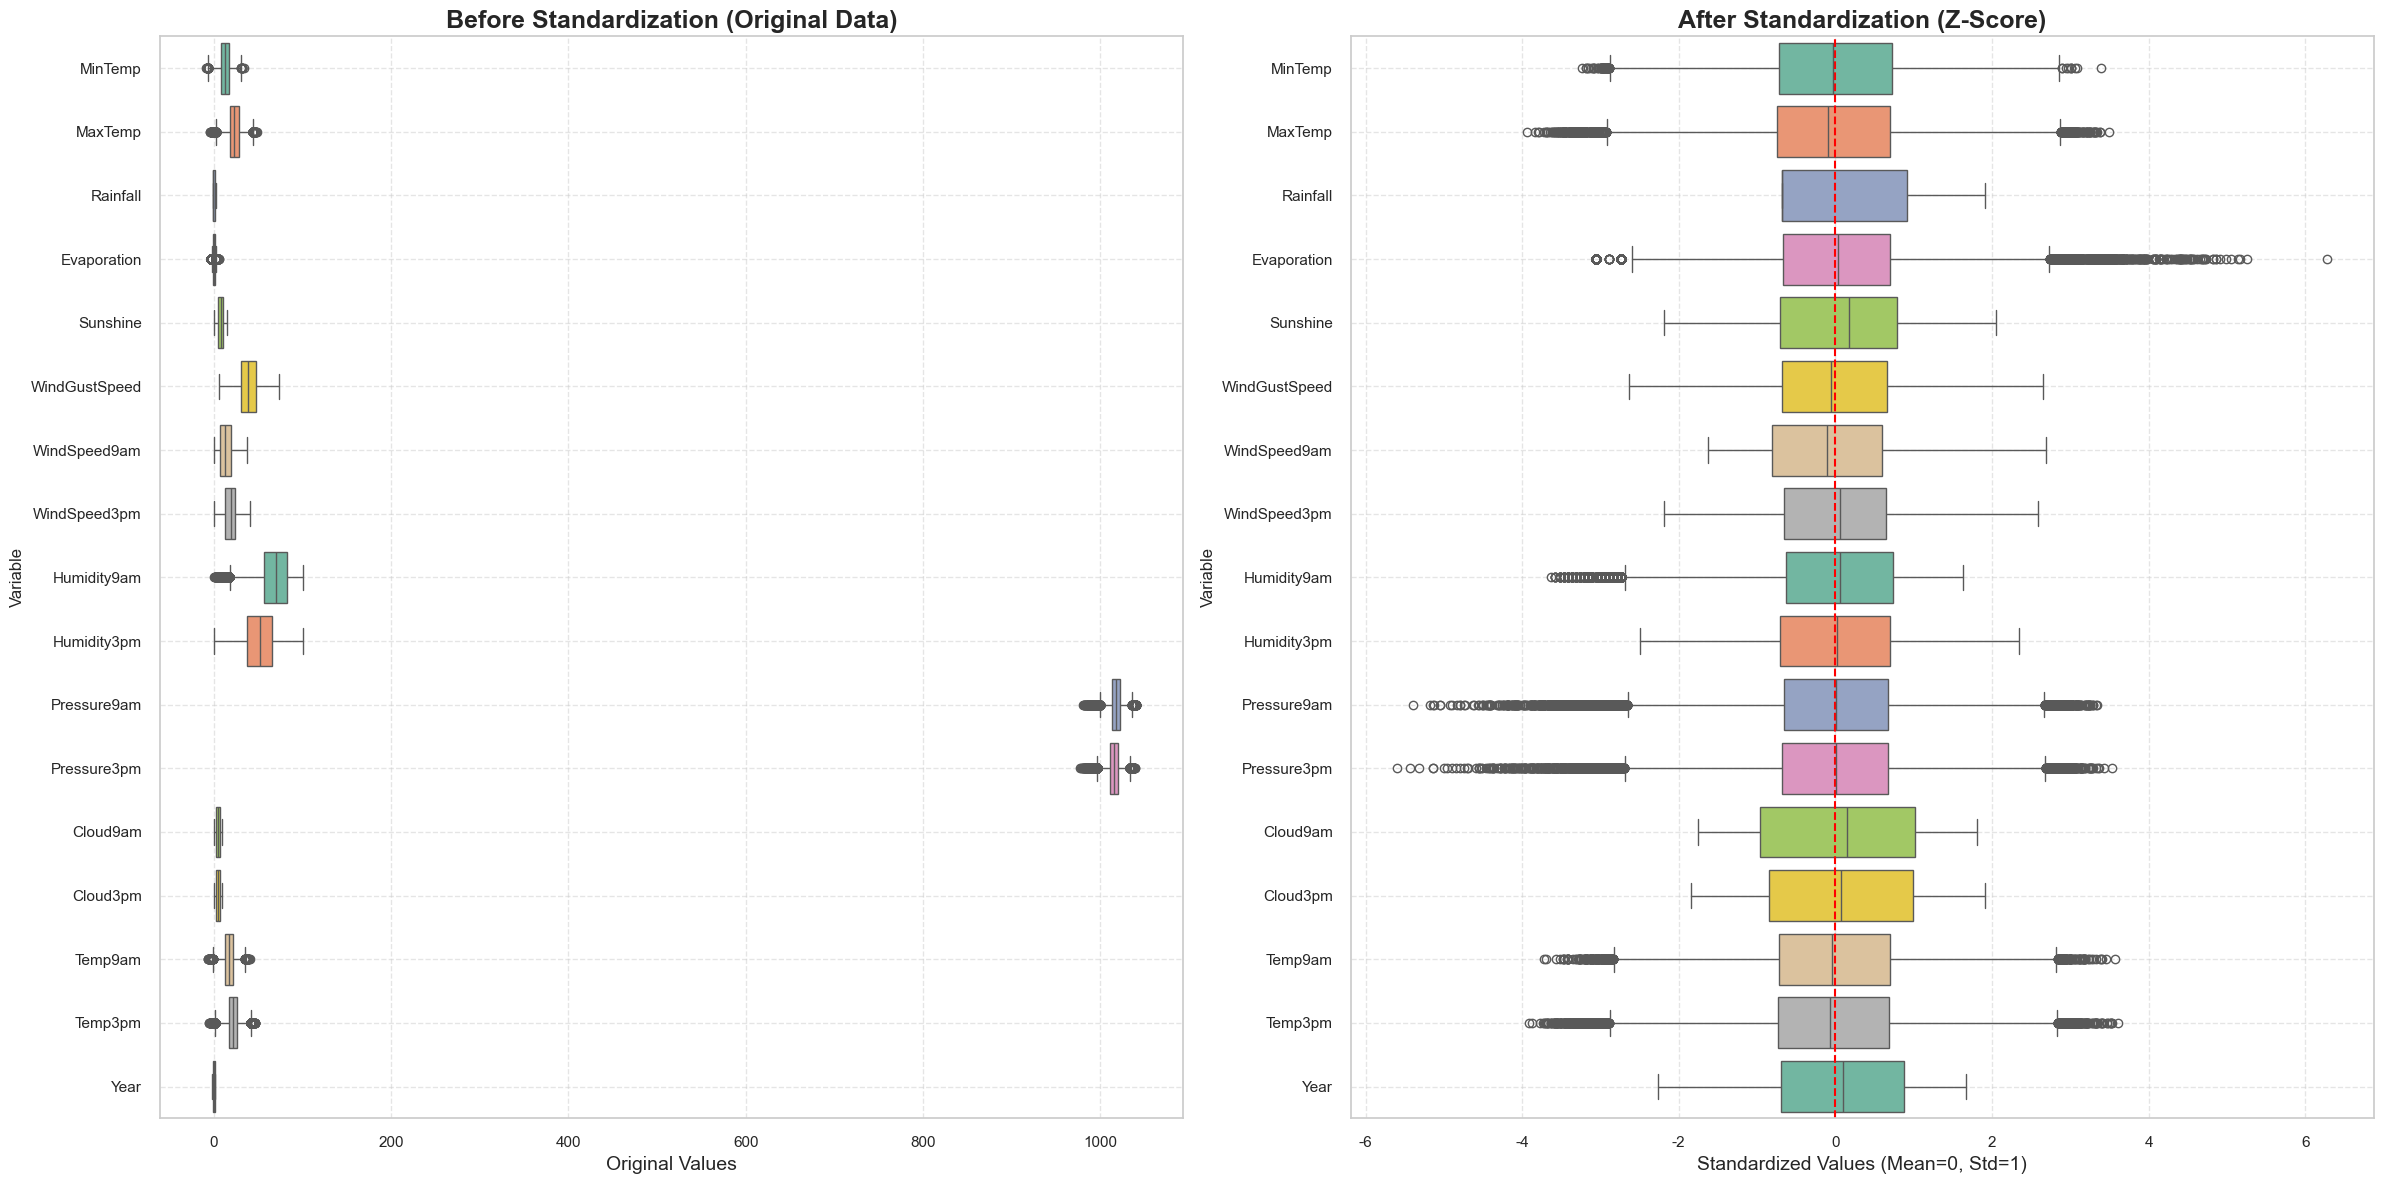

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载标准化前后的数据
df_raw = pd.read_csv('weatherAUS_Encoded_Final.csv')
df_scaled = pd.read_csv('weatherAUS_Modeling_Ready.csv')

# 定义可视化的连续变量
cols_to_plot = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year'
]

# 过滤有效列
cols = [c for c in cols_to_plot if c in df_raw.columns]

# 转换为长格式以适配 Seaborn
df_long_raw = df_raw[cols].melt(var_name='Variable', value_name='Value')
df_long_scaled = df_scaled[cols].melt(var_name='Variable', value_name='Value')

# 绘图对比
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# 左图：原始数据分布
sns.boxplot(data=df_long_raw, x='Value', y='Variable', ax=axes[0], orient='h', palette="Set2")
axes[0].set_title('Before Standardization (Original Data)', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Original Values', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 右图：标准化后数据分布
sns.boxplot(data=df_long_scaled, x='Value', y='Variable', ax=axes[1], orient='h', palette="Set2")
axes[1].set_title('After Standardization (Z-Score)', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Standardized Values (Mean=0, Std=1)', fontsize=14)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5) # 0均值基准线
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Heatmap saved to: correlation_heatmap.png


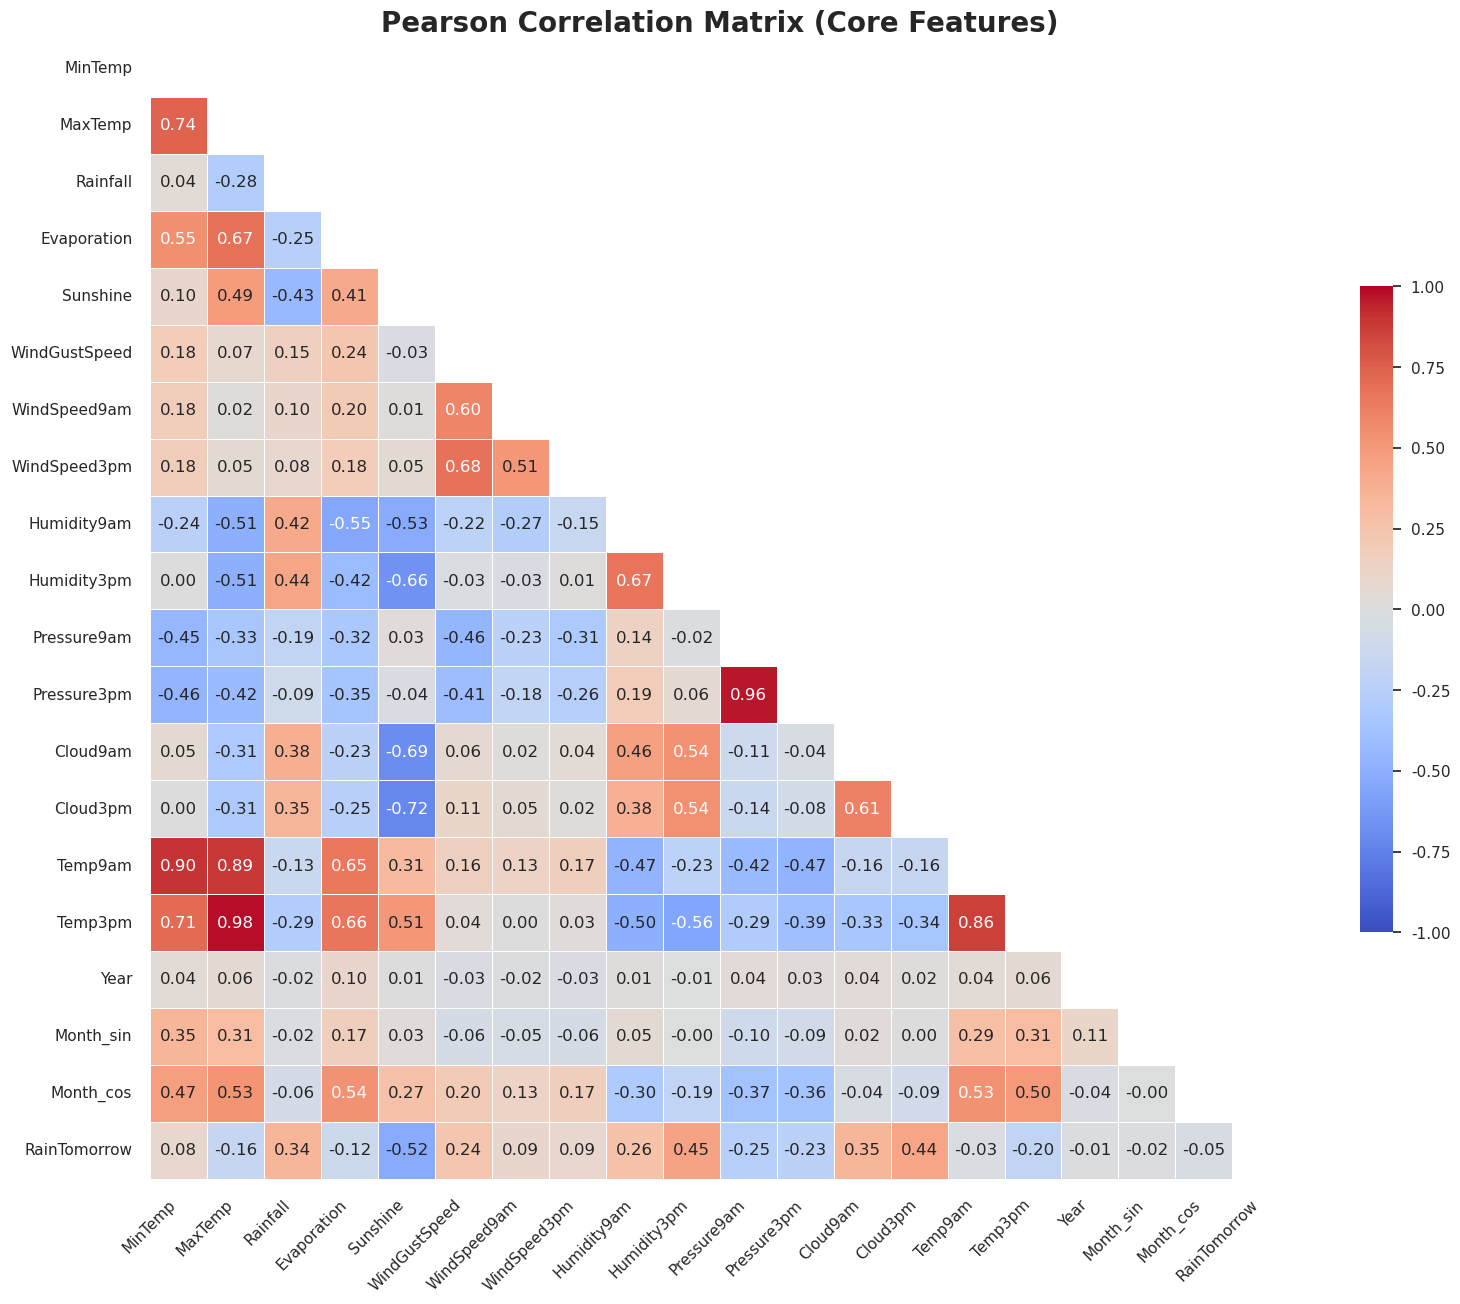


High Correlation Detection (> 0.9):
 - Redundant Pair: Pressure3pm     <--> Pressure9am     (Coef: 0.961)
 - Redundant Pair: Temp9am         <--> MinTemp         (Coef: 0.902)
 - Redundant Pair: Temp3pm         <--> MaxTemp         (Coef: 0.983)


In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 绘图配置
sns.set(style="white")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
filename = 'weatherAUS_Modeling_Ready.csv'
try:
    df = pd.read_csv(filename)
except FileNotFoundError:
    print(f"Error: {filename} not found.")
    exit()

# 筛选核心物理变量与时间特征
cols_to_analyze = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
    'Year', 'Month_sin', 'Month_cos', 'RainTomorrow'
]

# 过滤有效列
cols_to_analyze = [c for c in cols_to_analyze if c in df.columns]

# 计算 Pearson 相关系数
corr_matrix = df[cols_to_analyze].corr(method='pearson')

# 绘制热力图
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 遮挡上三角

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm',     
    vmax=1.0, vmin=-1.0, 
    center=0, 
    annot=True,          
    fmt='.2f',           
    square=True,         
    linewidths=.5,       
    cbar_kws={"shrink": .5}
)

plt.title('Pearson Correlation Matrix (Core Features)', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

output_file = 'correlation_heatmap.png'
plt.savefig(output_file, dpi=300)
print(f"Heatmap saved to: {output_file}")
plt.show()

# 检测高度共线性特征 (Threshold > 0.9)
print("\nHigh Correlation Detection (> 0.9):")
abs_corr = corr_matrix.abs()
upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (column, index, corr_matrix.loc[index, column])
    for column in upper_tri.columns
    for index in upper_tri.index
    if upper_tri.loc[index, column] > 0.9 
]

if not high_corr_pairs:
    print("No features exceed the 0.9 correlation threshold.")
else:
    for col, idx, val in high_corr_pairs:
        print(f" - Redundant Pair: {col:<15} <--> {idx:<15} (Coef: {val:.3f})")

In [40]:
import pandas as pd

print("Starting feature selection...")

# 读取标准化后的数据
input_filename = 'weatherAUS_Modeling_Ready.csv'

try:
    df = pd.read_csv(input_filename)
    print(f"Data loaded: {input_filename} | Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File {input_filename} not found.")
    exit()

# 定义需剔除的高共线性变量
cols_to_drop = ['Pressure9am', 'Temp9am', 'Temp3pm']

# 检查列是否存在并执行剔除
existing_cols = [c for c in cols_to_drop if c in df.columns]

if existing_cols:
    df.drop(columns=existing_cols, inplace=True)
    print(f"Dropped redundant columns: {existing_cols}")
else:
    print("No specified columns found to drop.")

# 验证最终数据维度
print(f"Post-selection shape: {df.shape}")

# 保存最终建模文件
output_filename = 'weatherAUS_Final_For_Modeling.csv'
df.to_csv(output_filename, index=False)

print(f"Final modeling dataset saved to: {output_filename}")

Starting feature selection...
Data loaded: weatherAUS_Modeling_Ready.csv | Shape: (142193, 114)
Dropped redundant columns: ['Pressure9am', 'Temp9am', 'Temp3pm']
Post-selection shape: (142193, 111)
Final modeling dataset saved to: weatherAUS_Final_For_Modeling.csv


Loading data...

Running Decision Tree...

[Decision Tree] Top 15 Features:
             Feature  Importance
            Sunshine    0.499695
         Humidity3pm    0.147021
         Pressure3pm    0.095593
            Cloud3pm    0.063111
       WindGustSpeed    0.055590
         Evaporation    0.023596
            Cloud9am    0.018748
            Rainfall    0.013458
             MaxTemp    0.010960
         Humidity9am    0.006799
             MinTemp    0.006001
Location_MountGinini    0.005027
                Year    0.004480
        WindSpeed3pm    0.004321
        WindSpeed9am    0.004206
Plot saved: feature_importance_Decision_Tree.png


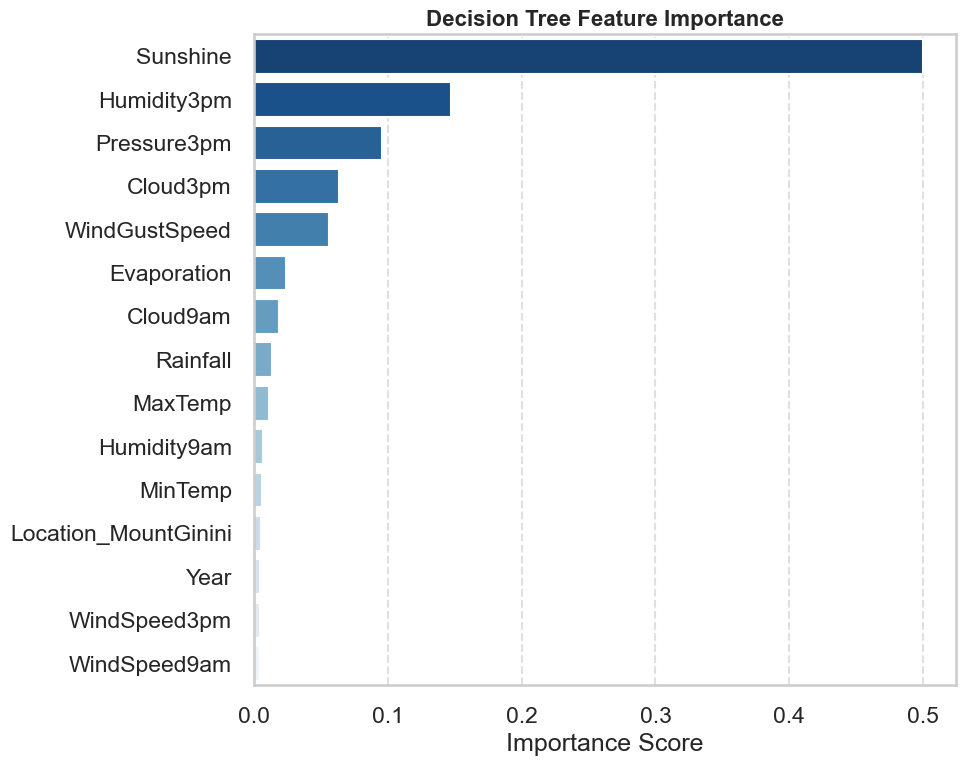


Running Random Forest...

[Random Forest] Top 15 Features:
      Feature  Importance
     Sunshine    0.134152
  Humidity3pm    0.102116
     Cloud3pm    0.099092
  Pressure3pm    0.063324
WindGustSpeed    0.050607
     Cloud9am    0.047938
  Humidity9am    0.039350
  Evaporation    0.037320
     Rainfall    0.036978
      MinTemp    0.036336
      MaxTemp    0.036318
    RainToday    0.028462
 WindSpeed3pm    0.025664
 WindSpeed9am    0.024011
         Year    0.020448
Plot saved: feature_importance_Random_Forest.png


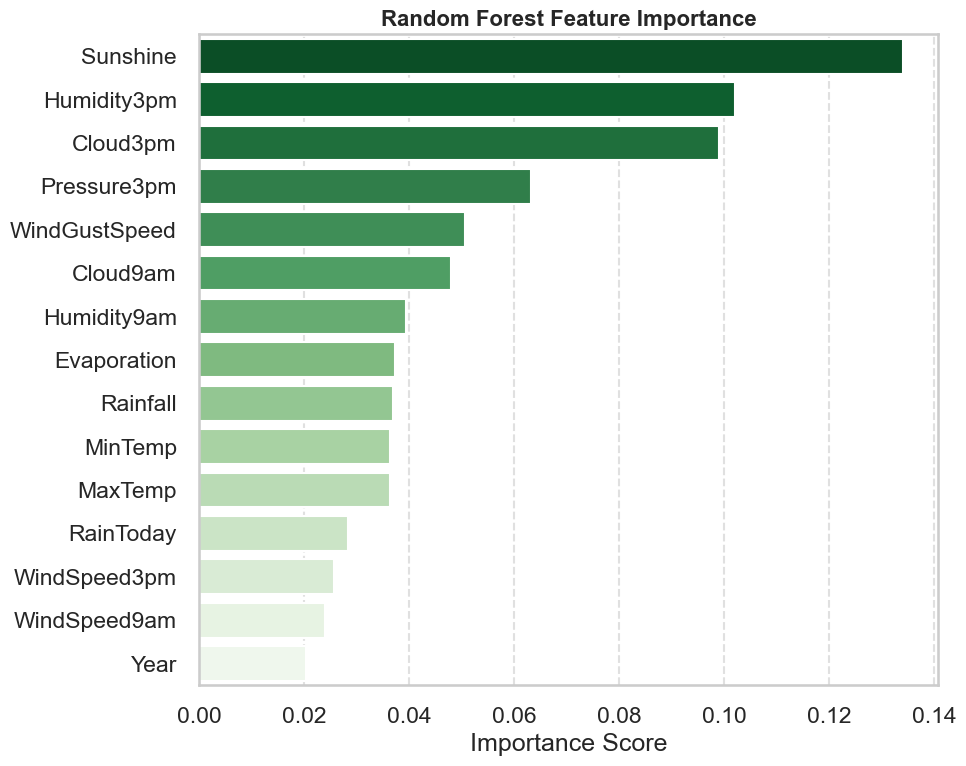


Running Lasso...

[Lasso (L1)] Top 15 Features:
                  Feature  Importance
                 Sunshine   -1.160659
              Humidity3pm    0.939798
            WindGustSpeed    0.733639
              Pressure3pm   -0.500294
                  MaxTemp    0.481928
                 Cloud3pm    0.427757
                 Rainfall    0.299211
                 Cloud9am   -0.250958
                  MinTemp   -0.195033
Location_MelbourneAirport   -0.140057
     Location_MountGinini   -0.132394
                Month_cos   -0.131123
      Location_Wollongong   -0.130791
          Location_Hobart   -0.125694
         Location_Woomera   -0.124672
Plot saved: feature_importance_Lasso_L1.png


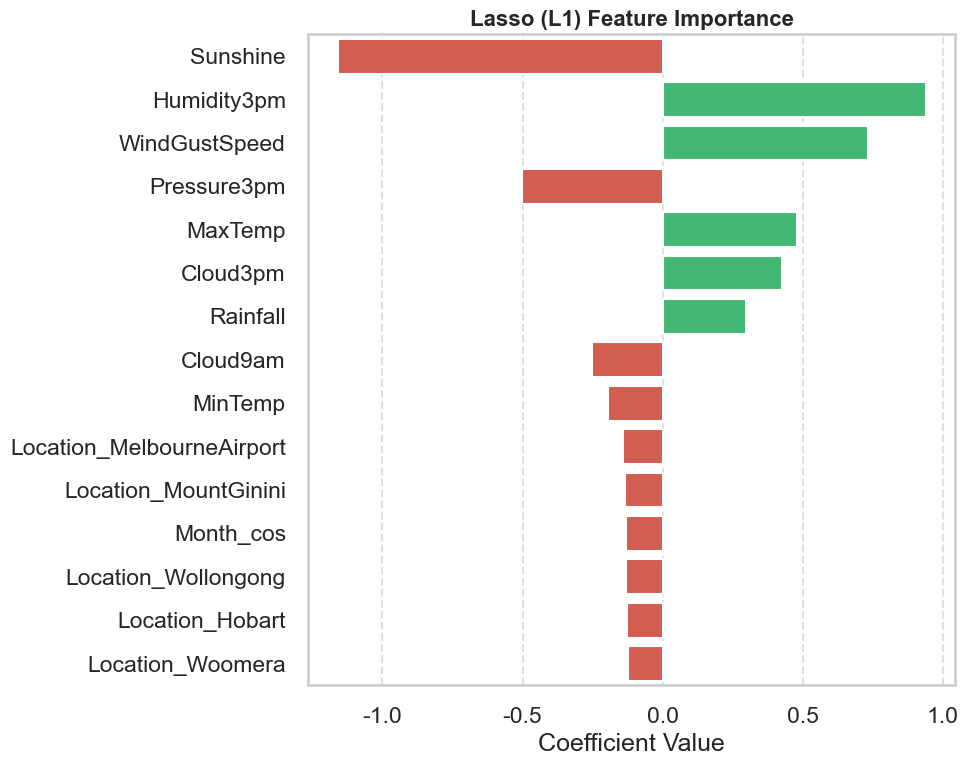


Running XGBoost...

[XGBoost] Top 15 Features:
             Feature  Importance
            Sunshine    0.085089
         Humidity3pm    0.035535
            Cloud3pm    0.031911
Location_Witchcliffe    0.030863
Location_MountGinini    0.022019
         Pressure3pm    0.020292
       WindGustSpeed    0.020189
  Location_NorahHead    0.016538
 Location_Wollongong    0.015724
 Location_SalmonGums    0.015145
    Location_Walpole    0.015091
      WindDir3pm_NNE    0.014462
      Location_Perth    0.014426
    Location_Penrith    0.013854
   Location_Ballarat    0.013367
Plot saved: feature_importance_XGBoost.png


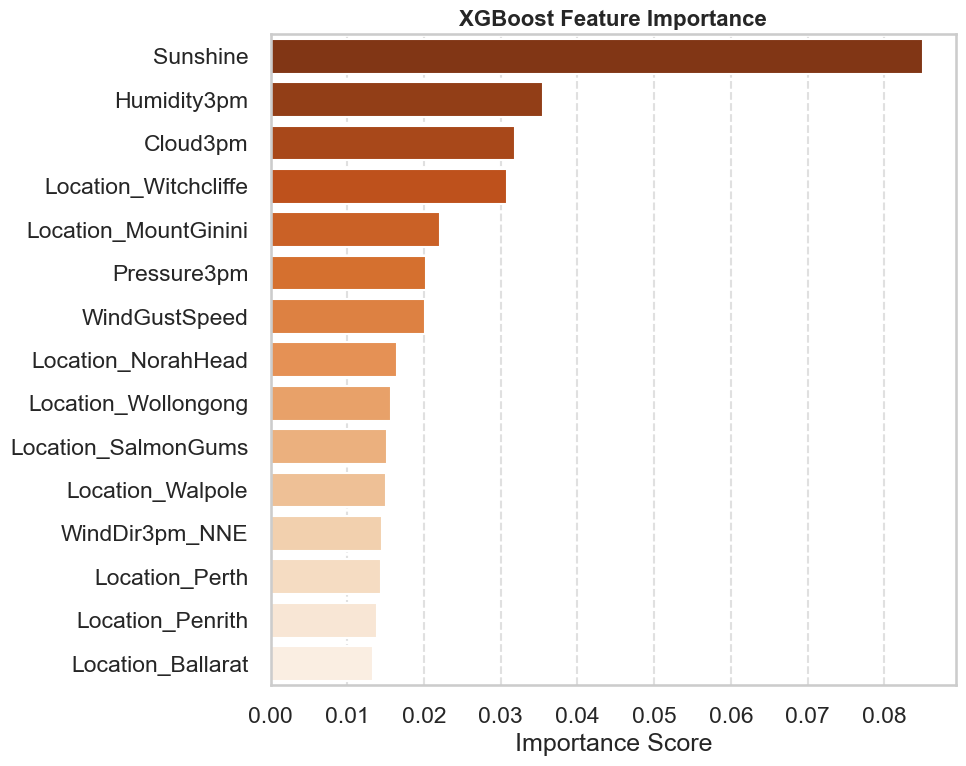

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# 配置绘图参数
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid", context="talk")

# 数据加载与划分
print("Loading data...")
df = pd.read_csv('weatherAUS_Final_For_Modeling.csv')
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化 (用于线性模型)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

def report_feature_importance(name, features, values, color_palette, top_n=15):
    # 构建特征重要性DataFrame
    feat_df = pd.DataFrame({'Feature': features, 'Importance': values})
    feat_df['Abs_Importance'] = feat_df['Importance'].abs()
    feat_df = feat_df.sort_values(by='Abs_Importance', ascending=False).head(top_n)
    
    # 打印Top N特征
    print(f"\n[{name}] Top {top_n} Features:")
    print(feat_df[['Feature', 'Importance']].to_string(index=False))
    
    # 绘图
    plt.figure(figsize=(10, 8))
    
    if name == 'Lasso (L1)':
        colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in feat_df['Importance']]
        sns.barplot(x='Importance', y='Feature', data=feat_df, palette=colors)
        plt.xlabel('Coefficient Value')
    else:
        sns.barplot(x='Importance', y='Feature', data=feat_df, palette=color_palette)
        plt.xlabel('Importance Score')
        
    plt.title(f'{name} Feature Importance', fontsize=16, fontweight='bold')
    plt.ylabel('')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    filename = f"feature_importance_{name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(filename, dpi=300)
    print(f"Plot saved: {filename}")
    plt.show()

# 1. Decision Tree
print("\nRunning Decision Tree...")
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
report_feature_importance("Decision Tree", X_train.columns, dt.feature_importances_, "Blues_r")

# 2. Random Forest
print("\nRunning Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
report_feature_importance("Random Forest", X_train.columns, rf.feature_importances_, "Greens_r")

# 3. Lasso (L1 Regularization)
print("\nRunning Lasso...")
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.05, random_state=42)
lasso.fit(X_train_scaled, y_train)
report_feature_importance("Lasso (L1)", X_train.columns, lasso.coef_[0], "coolwarm")

# 4. XGBoost
print("\nRunning XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
report_feature_importance("XGBoost", X_train.columns, xgb.feature_importances_, "Oranges_r")

Training Feature Selection Models...
Selected 17 features: ['Sunshine', 'Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Cloud3pm', 'Evaporation', 'MaxTemp', 'MinTemp', 'Cloud9am', 'Humidity9am', 'WindSpeed9am', 'Rainfall', 'WindSpeed3pm', 'Year', 'Month_cos', 'Location_MountGinini', 'Location_Wollongong']
Chart saved.


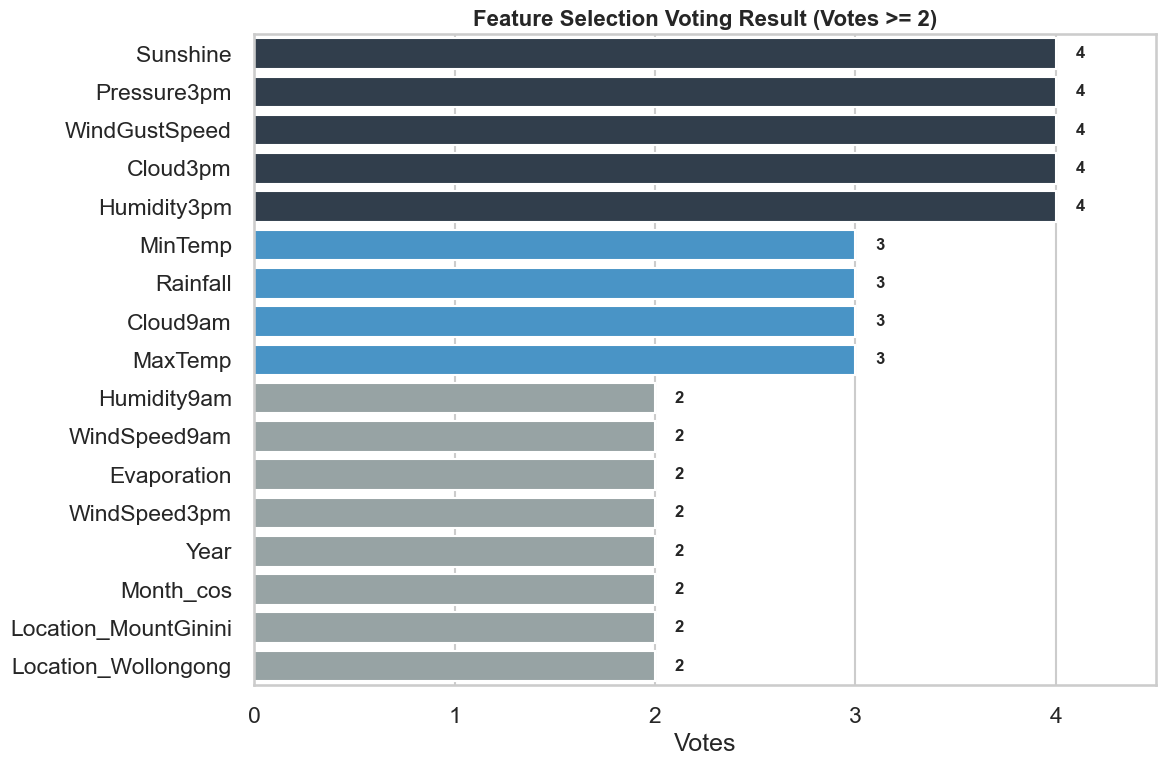

Final dataset saved: weatherAUS_Selected_Features.csv


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# 绘图配置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid", context="talk")

# 1. 加载数据
filename = 'weatherAUS_Final_For_Modeling.csv'
try:
    df = pd.read_csv(filename)
except FileNotFoundError:
    print(f"Error: {filename} not found.")
    exit()

X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# 划分训练集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化 (Lasso专用)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# 2. 多模型特征筛选
top_n = 15
candidates = []

print("Training Feature Selection Models...")

# Decision Tree
dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
candidates.extend(pd.Series(dt.feature_importances_, index=X_train.columns).nlargest(top_n).index.tolist())

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
candidates.extend(pd.Series(rf.feature_importances_, index=X_train.columns).nlargest(top_n).index.tolist())

# Lasso
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.05, random_state=42).fit(X_train_scaled, y_train)
candidates.extend(pd.Series(np.abs(lasso.coef_[0]), index=X_train.columns).nlargest(top_n).index.tolist())

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
candidates.extend(pd.Series(xgb.feature_importances_, index=X_train.columns).nlargest(top_n).index.tolist())

# 3. 投票统计
vote_counts = Counter(candidates)
votes_df = pd.DataFrame.from_dict(vote_counts, orient='index', columns=['Votes'])
votes_df.index.name = 'Feature'
votes_df = votes_df.reset_index()

# 筛选票数 >= 2 的特征
final_mask = votes_df['Votes'] >= 2
final_features = votes_df[final_mask]['Feature'].tolist()
votes_df_final = votes_df[final_mask].sort_values(by='Votes', ascending=False)

print(f"Selected {len(final_features)} features: {final_features}")

# 4. 绘图 (修复版：强制显示所有标签)
plt.figure(figsize=(12, 8))
colors = ['#2c3e50' if v == 4 else '#3498db' if v == 3 else '#95a5a6' for v in votes_df_final['Votes']]

ax = sns.barplot(data=votes_df_final, x='Votes', y='Feature', palette=colors)

plt.title('Feature Selection Voting Result (Votes >= 2)', fontsize=16, fontweight='bold')
plt.xlabel('Votes')
plt.ylabel('')
plt.xlim(0, 4.5)
plt.xticks(range(5))

# 遍历每个柱子添加数值标签
for p in ax.patches:
    width = p.get_width()
    if width > 0: # 避免空柱子报错
        ax.text(
            width + 0.1, 
            p.get_y() + p.get_height() / 2, 
            f'{int(width)}', 
            ha='left', 
            va='center',
            fontsize=12,
            fontweight='bold'
        )

plt.tight_layout()
plt.savefig('feature_selection_voting_result.png', dpi=300)
print("Chart saved.")
plt.show()

# 5. 保存最终数据
output_file = 'weatherAUS_Selected_Features.csv'
df[final_features + ['RainTomorrow']].to_csv(output_file, index=False)
print(f"Final dataset saved: {output_file}")

Starting model comparison (RF, LR, XGB)...
Data loaded: (142193, 111)
Class imbalance ratio: 3.45
Training Random Forest...
 - AUC: 0.9304 (3.60s)
Training Logistic Regression...
 - AUC: 0.9060 (1.88s)
Training XGBoost...
 - AUC: 0.9322 (1.05s)
Core Features (Intersection): ['Sunshine', 'Cloud3pm', 'Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Rainfall', 'Location_MountGinini', 'Location_NorahHead']
Comparison chart saved.


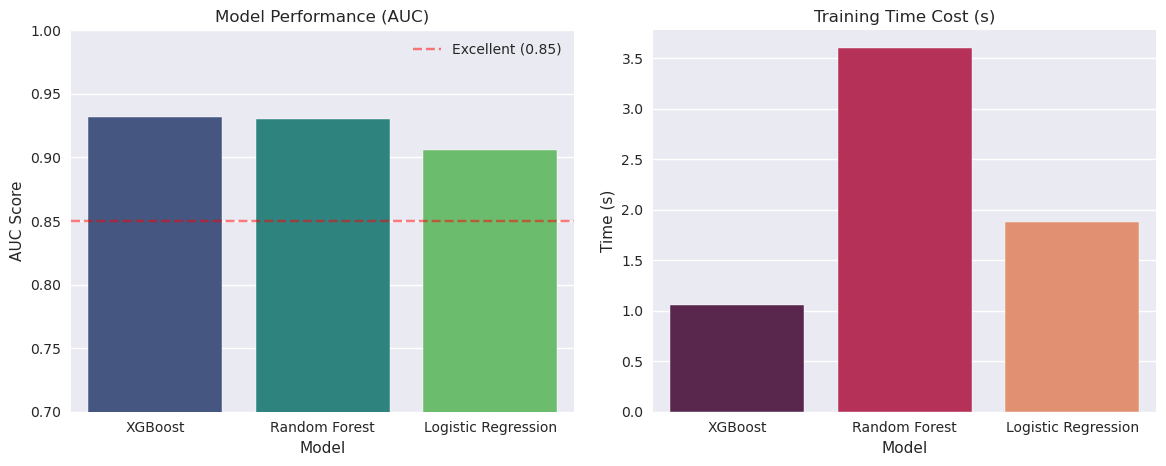

Best Model: XGBoost (AUC: 0.9322)


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import xgboost as xgb

# 全局配置
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']

print("Starting model comparison (RF, LR, XGB)...")

# 加载数据
file_path = 'weatherAUS_Final_For_Modeling.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Data loaded: {df.shape}")
except FileNotFoundError:
    print(f"Error: {file_path} not found.")
    exit()

# 准备训练集
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 模型列表与结果容器
model_metrics = []
feature_importance_dict = {}
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1) # XGBoost 权重
print(f"Class imbalance ratio: {ratio:.2f}")

# 1. Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

s = time.time()
rf.fit(X_train, y_train)
t = time.time() - s

auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
model_metrics.append({'Model': 'Random Forest', 'AUC': auc_rf, 'Time': t})

imp_rf = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
feature_importance_dict['Random Forest'] = imp_rf.head(10).index.tolist()
print(f" - AUC: {auc_rf:.4f} ({t:.2f}s)")

# 2. Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=2000, class_weight='balanced', random_state=42)

s = time.time()
lr.fit(X_train, y_train)
t = time.time() - s

auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
model_metrics.append({'Model': 'Logistic Regression', 'AUC': auc_lr, 'Time': t})

coefs = pd.Series(np.abs(lr.coef_[0]), index=feature_names).sort_values(ascending=False)
feature_importance_dict['Logistic Regression'] = coefs.head(10).index.tolist()
print(f" - AUC: {auc_lr:.4f} ({t:.2f}s)")

# 3. XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, scale_pos_weight=ratio, random_state=42, n_jobs=-1)

s = time.time()
xgb_model.fit(X_train, y_train)
t = time.time() - s

auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
model_metrics.append({'Model': 'XGBoost', 'AUC': auc_xgb, 'Time': t})

imp_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)
feature_importance_dict['XGBoost'] = imp_xgb.head(10).index.tolist()
print(f" - AUC: {auc_xgb:.4f} ({t:.2f}s)")

# 核心特征交叉验证
all_feats = []
for m, feats in feature_importance_dict.items():
    all_feats.extend(feats)
top_features = [f for f, c in Counter(all_feats).items() if c >= 2]
print(f"Core Features (Intersection): {top_features}")

# 结果可视化
metrics_df = pd.DataFrame(model_metrics).sort_values(by='AUC', ascending=False)

plt.figure(figsize=(12, 5))

# Subplot 1: AUC
plt.subplot(1, 2, 1)
sns.barplot(data=metrics_df, x='Model', y='AUC', palette='viridis')
plt.ylim(0.7, 1.0) 
plt.axhline(0.85, color='red', linestyle='--', alpha=0.5, label='Excellent (0.85)')
plt.title('Model Performance (AUC)')
plt.ylabel('AUC Score')
plt.legend()

# Subplot 2: Time
plt.subplot(1, 2, 2)
sns.barplot(data=metrics_df, x='Model', y='Time', palette='rocket')
plt.title('Training Time Cost (s)')
plt.ylabel('Time (s)')

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300)
print("Comparison chart saved.")
plt.show()

# 输出最佳模型
best_model = metrics_df.iloc[0]
print(f"Best Model: {best_model['Model']} (AUC: {best_model['AUC']:.4f})")

>>> [4.4.1 & 4.4.2] Performance bar plots saved.


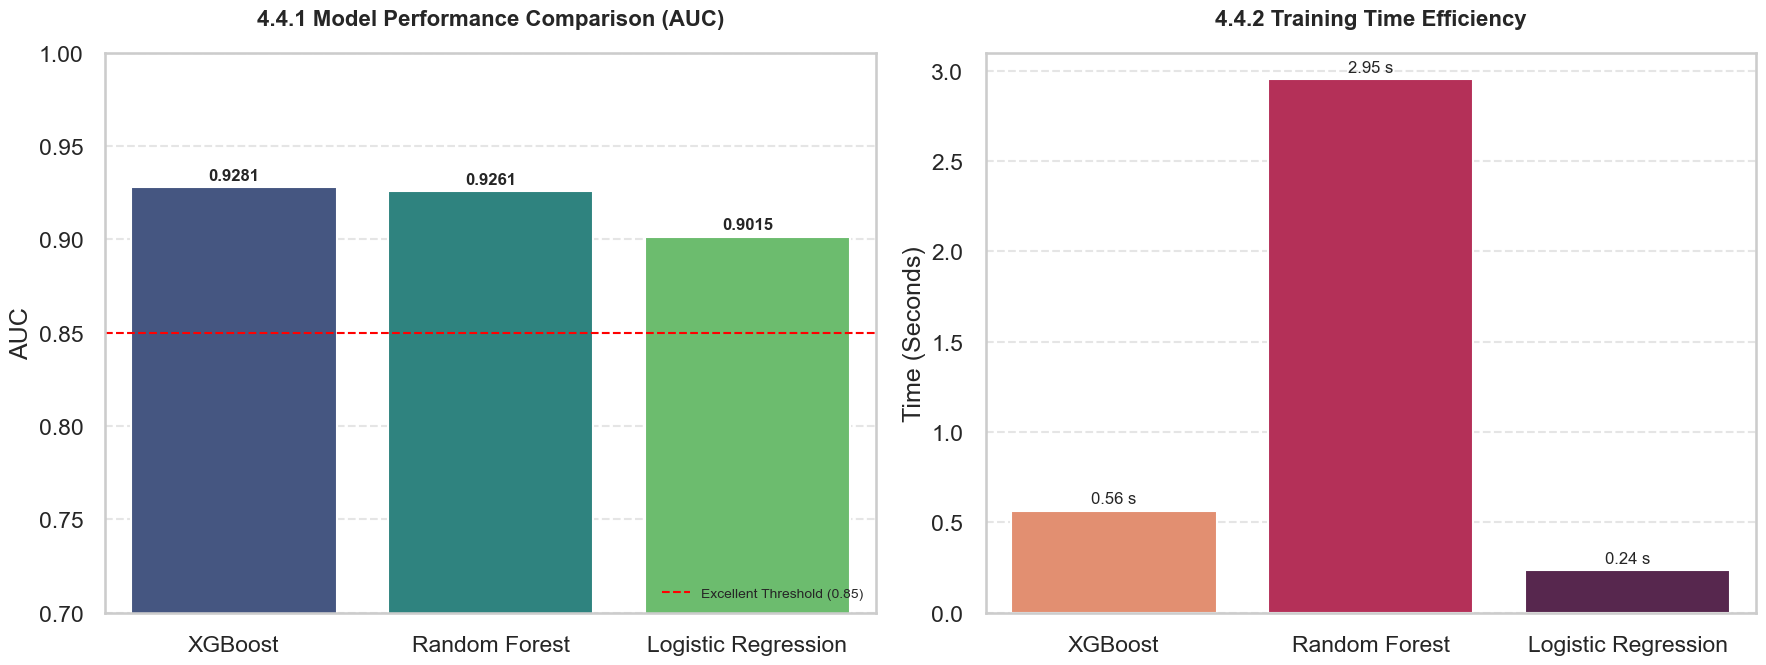

>>> [4.4.3] ROC Curves saved.


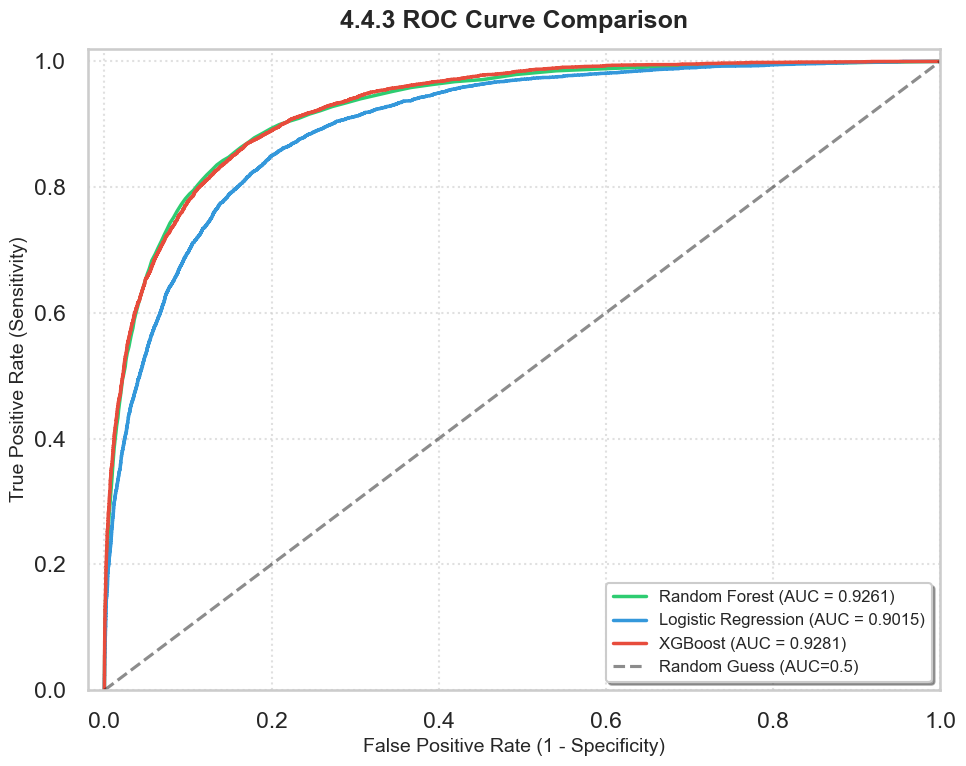


>>> Generating Confusion Matrix for Champion Model: [XGBoost]...
>>> [4.4.4] Confusion Matrix saved.


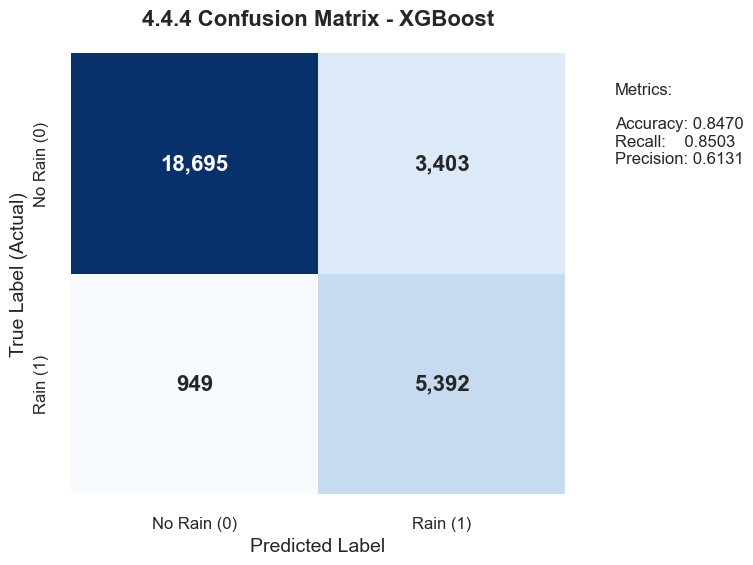

In [5]:
# ==========================================
# 4.4 Paper Visualizations (English Version)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, accuracy_score, recall_score, precision_score

# --- Global Style Settings (English Standards) ---
sns.set_theme(style="whitegrid", context="talk")
# Use standard fonts compatible with English
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 4.4.1 & 4.4.2: Model Performance & Efficiency
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: AUC Score Comparison ---
# Palette: Viridis (Professional & Colorblind-friendly)
barplot1 = sns.barplot(data=metrics_df, x='Model', y='AUC', ax=axes[0], palette='viridis')

axes[0].set_title('4.4.1 Model Performance Comparison (AUC)', fontsize=16, fontweight='bold', pad=20)
axes[0].set_ylim(0.7, 1.0) # Zoom in to show differences
axes[0].set_xlabel('')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Add numerical labels
for container in barplot1.containers:
    barplot1.bar_label(container, fmt='%.4f', padding=3, fontsize=12, fontweight='bold')

# Add "Excellent" Threshold Line
axes[0].axhline(0.85, color='red', linestyle='--', linewidth=1.5, label='Excellent Threshold (0.85)')
axes[0].legend(loc='lower right', fontsize=10)


# --- Plot 2: Training Time Efficiency ---
# Palette: Rocket_r (Warmer colors for time, inverted)
barplot2 = sns.barplot(data=metrics_df, x='Model', y='Time', ax=axes[1], palette='rocket_r')

axes[1].set_title('4.4.2 Training Time Efficiency', fontsize=16, fontweight='bold', pad=20)
axes[1].set_ylabel('Time (Seconds)')
axes[1].set_xlabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add time labels
for container in barplot2.containers:
    barplot2.bar_label(container, fmt='%.2f s', padding=3, fontsize=12)

plt.tight_layout()
plt.savefig('4.4_model_performance_comparison.png', dpi=300)
print(">>> [4.4.1 & 4.4.2] Performance bar plots saved.")
plt.show()


# ==========================================
# 4.4.3: ROC Curve Analysis
# ==========================================
plt.figure(figsize=(10, 8))

# 1. Random Forest
y_pred_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
auc_rf = metrics_df[metrics_df['Model'] == 'Random Forest']['AUC'].values[0]
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2.5, color='#2ecc71')

# 2. Logistic Regression
y_pred_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
auc_lr = metrics_df[metrics_df['Model'] == 'Logistic Regression']['AUC'].values[0]
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2.5, color='#3498db')

# 3. XGBoost
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)
auc_xgb = metrics_df[metrics_df['Model'] == 'XGBoost']['AUC'].values[0]
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2.5, color='#e74c3c')

# Reference Line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess (AUC=0.5)')

# Labels
plt.title('4.4.3 ROC Curve Comparison', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=14)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.02])

plt.tight_layout()
plt.savefig('4.4.3_roc_curve_comparison.png', dpi=300)
print(">>> [4.4.3] ROC Curves saved.")
plt.show()


# ==========================================
# 4.4.4: Confusion Matrix (Champion Model)
# ==========================================
best_model_name = metrics_df.iloc[0]['Model']
print(f"\n>>> Generating Confusion Matrix for Champion Model: [{best_model_name}]...")

# Select the model object
if best_model_name == 'Random Forest':
    best_model = rf
elif best_model_name == 'Logistic Regression':
    best_model = lr
else:
    best_model = xgb_model

# Predict
y_pred_final = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

# Plot Heatmap
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
                      annot_kws={"size": 16, "weight": "bold"}, cbar=False)

plt.title(f'4.4.4 Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label (Actual)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# Set English Tick Labels
tick_labels = ['No Rain (0)', 'Rain (1)']
heatmap.set_xticklabels(tick_labels, fontsize=12)
heatmap.set_yticklabels(tick_labels, fontsize=12)

# Calculate and Display Metrics
acc = accuracy_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)

# Add a text box with metrics
plt.text(2.2, 0.5, f"Metrics:\n\nAccuracy: {acc:.4f}\nRecall:    {rec:.4f}\nPrecision: {prec:.4f}", 
         fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

plt.tight_layout()
plt.savefig('4.4.4_confusion_matrix_best.png', dpi=300)
print(">>> [4.4.4] Confusion Matrix saved.")
plt.show()